# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:  Akhil Palakurthi**  **Roll No.: 1RUA25CSE0040** **Section: G**

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [2]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [3]:
import pandas as pd

df = pd.read_csv("gym_members_synthetic.csv")

df.head()

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights


## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [5]:
print("Shape of dataset:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

Shape of dataset:
(150, 6)

Data types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics:
       workout_duration_minutes  monthly_membership_fee_inr  \
count                   150.000                     150.000   
mean                     54.618                    2283.067   
std                      11.397                     984.837   
min                      27.800                     800.000   
25%                      48.050                    1515.000   
50%                      54.350                    2030.000   
75%                      62.875                    2825.000   
max                      81.000                    6420.000   

       attendance_percentage  weekly_visit_count  
count                150.000             150.000  
mean                  84.21

In [6]:
FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

results = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Mode": df[FEATURES].mode().iloc[0]
})

print(results)

print("\nMode of preferred_workout:")
print(df["preferred_workout"].mode())

                                Mean   Median    Mode
workout_duration_minutes      54.618    54.35    57.8
monthly_membership_fee_inr  2283.067  2030.00  1440.0
attendance_percentage         84.210    85.10    85.1
weekly_visit_count             3.337     2.40     2.3

Mode of preferred_workout:
0     Cardio
1    Weights
Name: preferred_workout, dtype: str


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer: The feature with the largest relative difference between the mean and median is **weekly_visit_count**. The mean (3.337) is noticeably higher than the median (2.4), suggesting that the distribution is **right-skewed**. Therefore, we would expect the tail of the distribution to stretch toward the higher number of weekly visits.**

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [7]:
df_copy = df.copy()

# Before adding the outlier
mean_before = df_copy["monthly_membership_fee_inr"].mean()
median_before = df_copy["monthly_membership_fee_inr"].median()

# Add ₹80,000 outlier
df_copy.loc[len(df_copy), "monthly_membership_fee_inr"] = 80000

# After adding the outlier
mean_after = df_copy["monthly_membership_fee_inr"].mean()
median_after = df_copy["monthly_membership_fee_inr"].median()

print("Before adding outlier:")
print("Mean:", mean_before)
print("Median:", median_before)

print("\nAfter adding outlier:")
print("Mean:", mean_after)
print("Median:", median_after)

Before adding outlier:
Mean: 2283.0666666666666
Median: 2030.0

After adding outlier:
Mean: 2797.748344370861
Median: 2030.0


In [8]:
import numpy as np

**Your answer: The mean increased significantly because it is calculated using every value in the dataset, so the extreme ₹80,000 value pulled the mean upward. The median changed very little because it depends on the middle value after sorting the data and is much less affected by a single extreme value.**

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [9]:
x = df["workout_duration_minutes"]

# Step 1: Calculate mean
mean = sum(x) / len(x)
print("Mean:", mean)

# Step 2: Calculate deviations
deviations = x - mean
print("\nDeviations:")
print(deviations)

# Step 3: Calculate squared deviations
squared_deviations = deviations ** 2
print("\nSquared deviations:")
print(squared_deviations)

# Step 4: Calculate sample variance
variance = sum(squared_deviations) / (len(x) - 1)
print("\nManual Sample Variance:", variance)

# Step 5: Calculate standard deviation
standard_deviation = variance ** 0.5
print("Manual Sample Standard Deviation:", standard_deviation)

# Step 6: Verify
print("\nVerification:")
print("NumPy Variance:", np.var(x, ddof=1))
print("NumPy Standard Deviation:", np.std(x, ddof=1))

Mean: 54.618

Deviations:
0      15.082
1      26.382
2       7.982
3      11.082
4      -5.318
        ...  
145     4.582
146    -1.818
147    11.482
148    25.482
149     8.582
Name: workout_duration_minutes, Length: 150, dtype: float64

Squared deviations:
0      227.467
1      696.010
2       63.712
3      122.811
4       28.281
        ...   
145     20.995
146      3.305
147    131.836
148    649.332
149     73.651
Name: workout_duration_minutes, Length: 150, dtype: float64

Manual Sample Variance: 129.89786174496643
Manual Sample Standard Deviation: 11.397274312087362

Verification:
NumPy Variance: 129.89786174496643
NumPy Standard Deviation: 11.397274312087362


### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

_(write here)_

In [10]:
iqr_results = []

for feature in FEATURES:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    iqr_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

iqr_table = pd.DataFrame(iqr_results)

print(iqr_table)

                      Feature        Q1        Q3       IQR  Lower Bound  \
0    workout_duration_minutes    48.050    62.875    14.825       25.812   
1  monthly_membership_fee_inr  1515.000  2825.000  1310.000     -450.000   
2       attendance_percentage    80.175    88.775     8.600       67.275   
3          weekly_visit_count     1.800     5.300     3.500       -3.450   

   Upper Bound  Outlier Count  
0       85.113              0  
1     4790.000              2  
2      101.675              1  
3       10.550              0  


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [11]:
from scipy.stats import skew, kurtosis

for feature in FEATURES:
    skewness = skew(df[feature])
    excess_kurtosis = kurtosis(df[feature])

    print("\n", feature)
    print("Skewness:", skewness)
    print("Excess Kurtosis:", excess_kurtosis)


 workout_duration_minutes
Skewness: 0.07987294609765831
Excess Kurtosis: -0.19428795225711282

 monthly_membership_fee_inr
Skewness: 1.1654051997158945
Excess Kurtosis: 1.7613343695829329

 attendance_percentage
Skewness: -0.5555062898582598
Excess Kurtosis: -0.3530188963520642

 weekly_visit_count
Skewness: 0.44110540465802844
Excess Kurtosis: -1.3693178201089702


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:
I predict that **weekly_visit_count** will be bimodal. There may be two distinct groups of gym members: casual members who visit only once or twice a week, and highly committed members who visit the gym much more frequently. Therefore, their weekly visit patterns may form two separate groups in the distribution.**

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

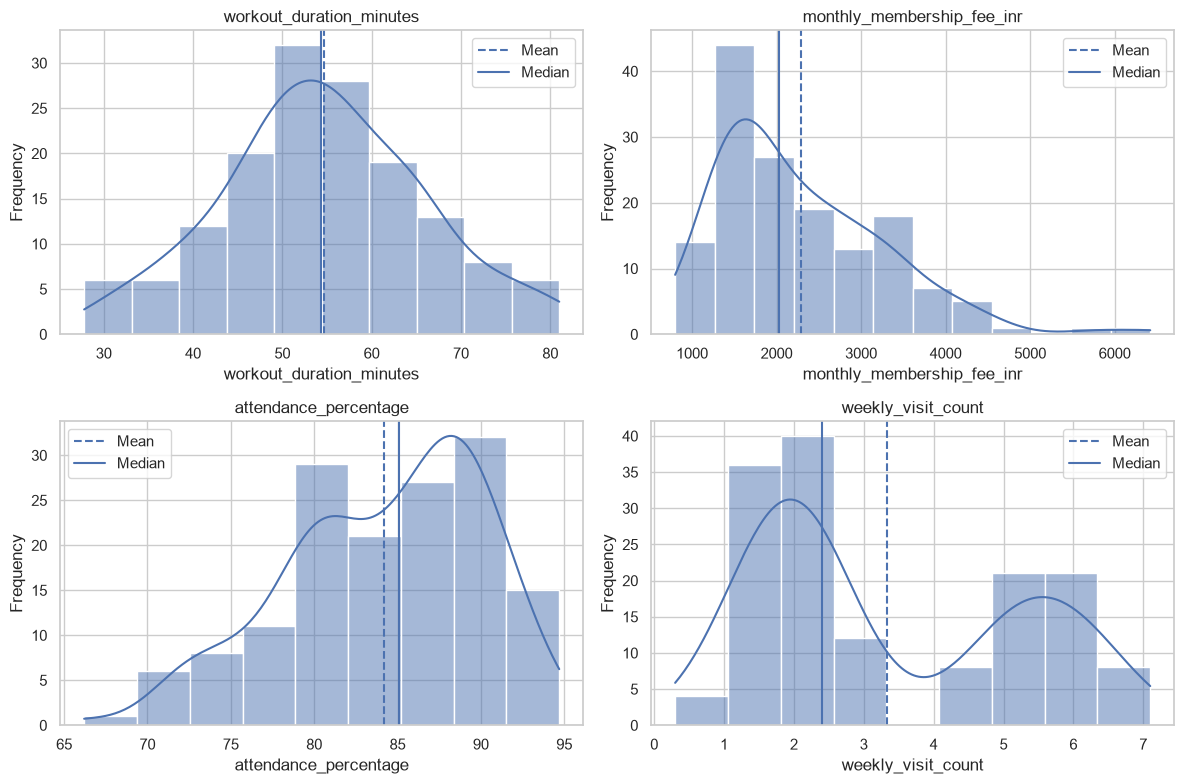

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flat, FEATURES):
    sns.histplot(df[feature], kde=True, ax=ax)

    mean_value = df[feature].mean()
    median_value = df[feature].median()

    ax.axvline(mean_value, linestyle="--", label="Mean")
    ax.axvline(median_value, linestyle="-", label="Median")

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer: The histogram confirms my prediction that **weekly_visit_count** is bimodal. It shows two distinct groups of gym members with different visiting patterns, representing members who visit less frequently and those who visit more frequently. The mean falls in a sensible region of the distribution rather than in an empty valley.**

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

   workout_duration_minutes  monthly_membership_fee_inr  \
0                     1.328                      -0.604   
1                     2.323                       0.170   
2                     0.703                      -0.095   
3                     0.976                       0.904   
4                    -0.468                      -1.256   

   attendance_percentage  weekly_visit_count  
0                 -2.137              -1.083  
1                  0.340              -0.605  
2                  0.818               0.938  
3                 -0.787               1.098  
4                 -0.600              -0.977  


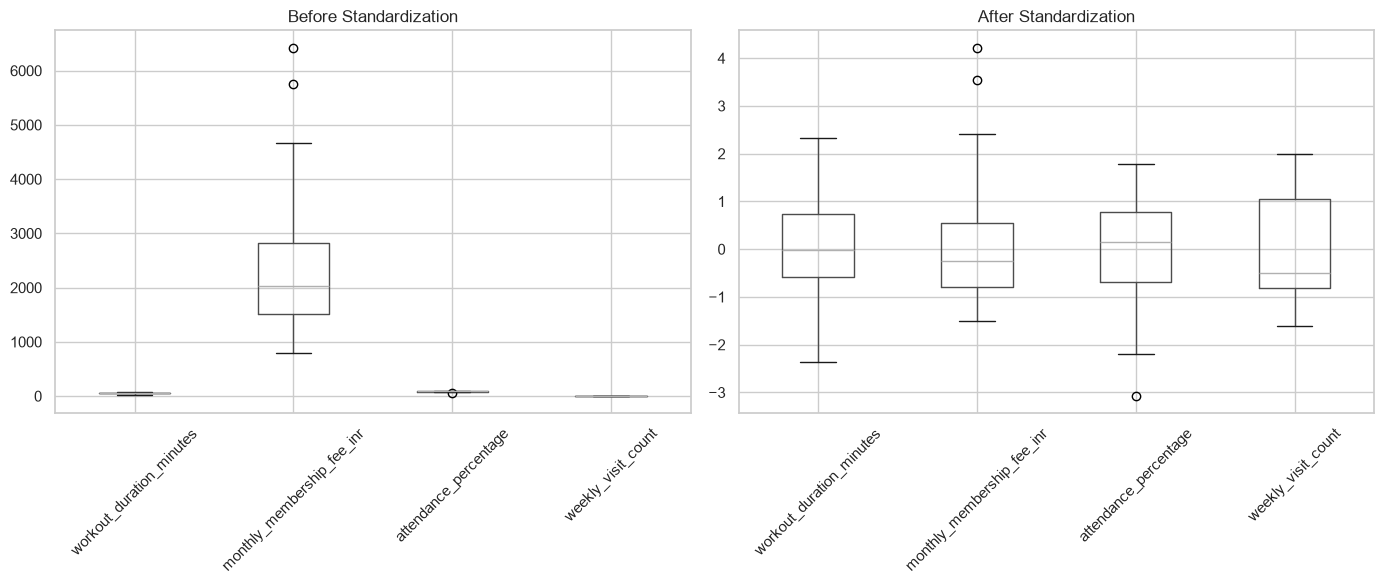

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standardized_data = scaler.fit_transform(df[FEATURES])

standardized_df = pd.DataFrame(
    standardized_data,
    columns=FEATURES
)

print(standardized_df.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df[FEATURES].boxplot(ax=axes[0])
axes[0].set_title("Before Standardization")
axes[0].tick_params(axis="x", rotation=45)

standardized_df.boxplot(ax=axes[1])
axes[1].set_title("After Standardization")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

_(write here)_

workout_duration_minutes vs attendance_percentage
Pearson correlation: -0.028185891696363277


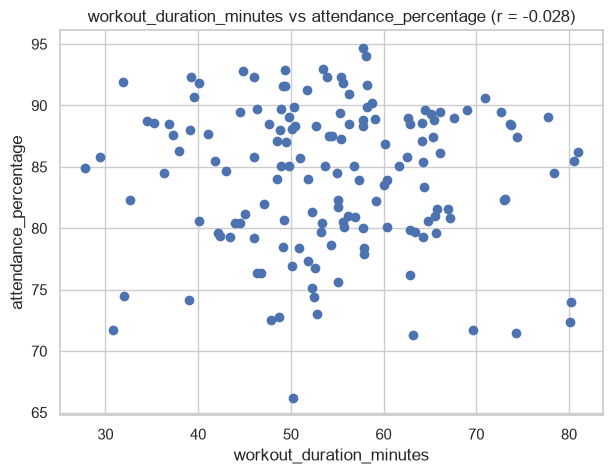

monthly_membership_fee_inr vs weekly_visit_count
Pearson correlation: -0.038818346329174185


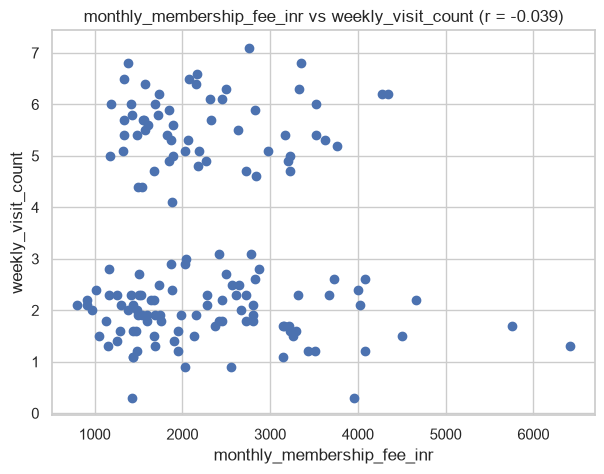

In [14]:
pairs = [
    ("workout_duration_minutes", "attendance_percentage"),
    ("monthly_membership_fee_inr", "weekly_visit_count")
]

for x_feature, y_feature in pairs:
    correlation = df[x_feature].corr(df[y_feature])

    print(x_feature, "vs", y_feature)
    print("Pearson correlation:", correlation)

    plt.figure(figsize=(7, 5))
    plt.scatter(df[x_feature], df[y_feature])
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"{x_feature} vs {y_feature} (r = {correlation:.3f})")
    plt.show()

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [15]:
summary_table = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Standard Deviation": df[FEATURES].std(),
    "IQR": df[FEATURES].quantile(0.75) - df[FEATURES].quantile(0.25),
    "Skewness": df[FEATURES].skew(),
    "Excess Kurtosis": df[FEATURES].kurt()
})

print(summary_table.round(3))

                                Mean   Median  Standard Deviation       IQR  \
workout_duration_minutes      54.618    54.35              11.397    14.825   
monthly_membership_fee_inr  2283.067  2030.00             984.837  1310.000   
attendance_percentage         84.210    85.10               5.874     8.600   
weekly_visit_count             3.337     2.40               1.886     3.500   

                            Skewness  Excess Kurtosis  
workout_duration_minutes       0.081           -0.160  
monthly_membership_fee_inr     1.177            1.863  
attendance_percentage         -0.561           -0.324  
weekly_visit_count             0.446           -1.375  


**Your answer (recommendation paragraph): For workout_duration_minutes, I recommend the mean and standard deviation, because its mean (54.618) and median (54.35) are very close, indicating little skew, while the standard deviation of about 11.397 provides a useful measure of its spread. For monthly_membership_fee_inr, the median and IQR are more appropriate because the mean (2283.067) is higher than the median (2030), suggesting right-skew caused by higher fees. For attendance_percentage, the mean and standard deviation are suitable because the mean (84.210) and median (85.10) are relatively close. For weekly_visit_count, the median and IQR are preferable because the mean (3.337) is substantially higher than the median (2.4), showing stronger right-skew and greater influence from higher visit counts.**


---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [16]:
attendance_by_workout = df.groupby("preferred_workout")["attendance_percentage"].mean()

print(attendance_by_workout)

preferred_workout
Cardio      83.558
CrossFit    82.325
Weights     85.526
Yoga        84.029
Name: attendance_percentage, dtype: float64


In [17]:
attendance_by_workout = (
    df.groupby("preferred_workout")["attendance_percentage"]
    .mean()
    .reset_index()
)

print(attendance_by_workout)

  preferred_workout  attendance_percentage
0            Cardio                 83.558
1          CrossFit                 82.325
2           Weights                 85.526
3              Yoga                 84.029


---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed